# Noise Hand Calculations Using the Level 1 Model

Este notebook calcula a mano el ruido de un NMOS con el modelo de primer orden (Level 1) de `razavi_cmos.lib` y lo compara contra una simulación `.noise` de ngspice (`Noise_Razavi.cir`). Las unidades son SI: metros, volts, amperes, hertz; las densidades espectrales están en V$^2$/Hz o A$^2$/Hz.

Se estudian tres circuitos de fuente común, todos con $V_{GS}=0.9$ V, $W=1\,\mu$m y $L=0.18\,\mu$m, que comparten el mismo transistor:

| Circuito | Carga | Qué aísla |
|---|---|---|
| **A** | Inductor ideal (corto en DC, abierto en AC) desde 0.9 V | El ruido del transistor solo ($V_{DS}=0.9$ V) |
| **B** | $R_D=10\,\text{k}\Omega$ desde $V_{DD}=1.8$ V | El ruido del transistor más el de la resistencia de carga |
| **C** | Igual que A, con $r_d=r_s=200\,\Omega$ en serie con drenador y fuente | El ruido de las resistencias parásitas |

El Level 1 de SPICE genera tres fuentes de ruido: térmico del canal, flicker (1/f) y térmico de $r_d$ y $r_s$. Este notebook parte de sus expresiones y de las ecuaciones de pequeña señal ya corregidas en `Hand_Calculations.ipynb`.

**Convención del código.** Para que se vea cada paso del cálculo, el código no define funciones propias: cada ecuación se escribe completa, una vez por circuito, y las variables llevan el sufijo del circuito (`_A`, `_B`, `_C`). Por eso hay líneas casi idénticas repetidas; la diferencia entre ellas es justamente la diferencia entre los circuitos.

## Imports

Se cargan NumPy y Matplotlib para los cálculos y las gráficas, `spicelib` para leer los archivos `.raw` de ngspice, y `prettytable` y `si_prefix` para mostrar los resultados en notación de ingeniería. Si la fuente Arial no está instalada, Matplotlib usa otra de la lista sin mostrar advertencias.

In [1]:
# Paso 1: importar las librerias
import logging
import re

import numpy as np                  # calculos numericos
import matplotlib.pyplot as plt     # graficas

from spicelib import RawRead        # lee los archivos .raw de ngspice

from si_prefix import si_format as num2eng   # imprime con prefijos de ingenieria (n, u, m, k...)
from prettytable import PrettyTable          # tablas de resultados

# Paso 2: configurar el estilo de las graficas
# Se usa Arial si esta instalada; si no, matplotlib toma la siguiente fuente de la lista.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # oculta avisos de fuente faltante
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

C_HAND = "#2a78d6"     # calculo a mano
C_SIM = "#eb6834"      # ngspice
C_AUX = "#52514e"      # lineas auxiliares

# Paso 3: regla del trapecio (se llama trapezoid en versiones recientes de numpy)
trapz = getattr(np, "trapezoid", None) or np.trapz

## Constantes y parámetros del modelo

La densidad espectral del ruido térmico depende de la temperatura de la simulación. ngspice usa `temp=27` °C, es decir $T=300.15$ K. La capacitancia de óxido por unidad de área es

$$C_{ox}=\frac{\epsilon_{ox}}{t_{ox}}, \qquad \epsilon_{ox}=3.9\,\epsilon_0,$$

con $\epsilon_0=8.854214871\times10^{-12}$ F/m, el valor que usa ngspice.

Además de los parámetros de `Hand_Calculations.ipynb`, el ruido necesita:

- $K_F$ y $A_F$: coeficiente y exponente del ruido flicker.
- $r_d$ y $r_s$: resistencias serie de drenador y fuente, que aportan su propio ruido térmico $4kT/R$.

Los valores de $K_F$ y $A_F$ de `razavi_cmos.lib` son didácticos: se calibraron contra sky130 y gf180mcuD para que el flicker tenga una magnitud comparable a la de un proceso real ($K_F=3\times10^{-29}$ en el NMOS y $3.5\times10^{-30}$ en el PMOS, con $A_F=1$). Con ellos la esquina del ruido 1/f del NMOS queda cerca de 51 MHz con esta geometría. Al final del notebook se resumen los hallazgos de esa calibración, y `Extraccion_KF_AF.ipynb` la reproduce paso a paso.

En LTspice el flicker del Level 1 usa otra fórmula y por eso otro valor de $K_F$; la sección *Diferencias entre ngspice y LTspice* (casi al final) lo explica.

In [2]:
# Paso 1: constantes fisicas y temperatura (ngspice usa temp = 27 C)
k = 1.380649e-23        # Constante de Boltzmann (J/K)
TEMP = 27.0             # Temperatura (C)
T = TEMP + 273.15       # Temperatura (K)
eps0 = 8.854214871e-12  # Permitividad del vacio (F/m)

# Paso 2: geometria del transistor y polarizacion (los tres circuitos comparten transistor)
W = 1e-6                # Ancho del canal (m)
L = 0.18e-6             # Largo del canal (m)
VGS = 0.9               # Voltaje compuerta-fuente (V)
VDD = 1.8               # Alimentacion del circuito B (V)
RD = 10e3               # Circuito B: resistencia de carga (ohm)

# Paso 3: parametros Level 1 (los mismos que en Hand_Calculations.ipynb)
kp = 100e-6             # Parametro de transconductancia de proceso (A/V**2)
VTH0 = 0.4              # Voltaje de umbral con VSB = 0 (V)
gamma = 0.4             # Coeficiente de efecto de cuerpo (V**0.5)
phi = 0.3               # Potencial de superficie (V)
lmbda = 0.1             # Modulacion de longitud de canal (1/V)
tox = 40e-10            # Espesor de oxido (m)

# Paso 4: parametros de ruido (los de razavi_cmos.lib, modelo nch)
kf = 3e-29              # Coeficiente flicker del NMOS (el PMOS usa 3.5e-30)
af = 1.0                # Exponente flicker
rd = 200.0              # Circuito C: resistencia serie de drenador (ohm)
rs = 200.0              # Circuito C: resistencia serie de fuente (ohm)

# Paso 5: capacitancias que cargan el nodo de salida (solo afectan el ruido de salida a alta frecuencia)
CGDO = 9.548e-10        # Traslape compuerta-drenador por unidad de ancho (F/m)
Cj = 9.81e-4            # Capacitancia de union de fondo (F/m**2)
Cjsw = 1.19e-10         # Capacitancia de union de pared lateral (F/m)
LD = 0.48e-6            # Longitud de difusion (m)

# Paso 6: cantidades derivadas
Cox = 3.9 * eps0 / tox          # Capacitancia de oxido por unidad de area (F/m**2)
beta = kp * W / L               # kp * W / L (A/V**2)
AS = W * LD                     # Area de la difusion de drenador (m**2)
PS = 2 * W + 2 * LD             # Perimetro de la difusion de drenador (m)
Cdb = Cj * AS + Cjsw * PS       # Capacitancia de union drenador-cuerpo (F)
Cgd = CGDO * W                  # En saturacion solo queda el traslape compuerta-drenador (F)
Cout = Cdb + Cgd                # La compuerta es tierra de AC: Cdb y Cgd ven el nodo de salida (F)

print(f"T = {T:.2f} K, 4kT = {4*k*T:.4e} J, Cox = {num2eng(Cox)}F/m^2, beta = {num2eng(beta)}A/V^2, Cout = {num2eng(Cout)}F")

T = 300.15 K, 4kT = 1.6576e-20 J, Cox = 8.6 mF/m^2, beta = 555.6 µA/V^2, Cout = 1.8 fF


## Punto de operación

El ruido del canal depende de $g_m$ y de $I_D$, así que primero se calcula el punto de operación con las mismas ecuaciones de `Hand_Calculations.ipynb`:

$$V_{TH}=V_{TH0}+\gamma\left(\sqrt{\phi+V_{SB}}-\sqrt{\phi}\right), \qquad V_{ov}=V_{GS}-V_{TH},$$
$$I_D=\frac{1}{2}k_p\frac{W}{L}V_{ov}^2(1+\lambda V_{DS}), \qquad g_m=k_p\frac{W}{L}V_{ov}(1+\lambda V_{DS}),$$
$$g_{mb}=g_m\frac{\gamma}{2\sqrt{\phi+V_{SB}}}, \qquad g_{ds}=\frac{\lambda I_D}{1+\lambda V_{DS}}.$$

### Circuito A

Con la carga ideal, $V_{DS}=0.9$ V y $V_{SB}=0$.

### Circuito B

El drenador está conectado a $V_{DD}$ por $R_D$, así que $V_{DS}=V_{DD}-R_DI_D$ y $I_D$ depende de $V_{DS}$ por la modulación de canal. Con $I_0=\frac{1}{2}k_p\frac{W}{L}V_{ov}^2$ y $I_D=I_0(1+\lambda V_{DS})$ se despeja

$$V_{DS}=\frac{V_{DD}-R_DI_0}{1+\lambda R_DI_0}.$$

### Circuito C

Con $r_s$ y $r_d$ en serie, el transistor intrínseco ve voltajes distintos a los externos:

$$V_{GS}'=V_{G}-I_Dr_s, \qquad V_{SB}'=I_Dr_s, \qquad V_{DS}'=V_{D}-I_D(r_d+r_s).$$

Como $V_{GS}'$, $V_{SB}'$ y $V_{DS}'$ dependen de $I_D$, y $I_D$ depende de ellos, el punto de operación se resuelve numéricamente con bisección sobre $I_D$.

In [3]:
# ===================== Circuito A: carga ideal =====================
# Paso 1: voltajes del circuito. El drenador esta fijo a 0.9 V y la fuente a tierra.
VDS_A = 0.9
VSB_A = 0.0

# Paso 2: voltaje de umbral con efecto de cuerpo y voltaje de sobreexcitacion
VTH_A = VTH0 + gamma * (np.sqrt(phi + VSB_A) - np.sqrt(phi))
Vov_A = VGS - VTH_A
VDSat_A = Vov_A                 # En saturacion se necesita VDS >= VDSat = VGS - VTH

# Paso 3: corriente de drenador y parametros de pequena senal
ID_A = 0.5 * beta * Vov_A**2 * (1 + lmbda * VDS_A)
gm_A = beta * Vov_A * (1 + lmbda * VDS_A)
gmb_A = gm_A * gamma / (2 * np.sqrt(phi + VSB_A))
gds_A = lmbda * ID_A / (1 + lmbda * VDS_A)


# ===================== Circuito B: carga resistiva RD =====================
# Paso 1: la fuente esta a tierra, asi que VSB = 0 y VTH no cambia
VSB_B = 0.0
VTH_B = VTH0 + gamma * (np.sqrt(phi + VSB_B) - np.sqrt(phi))
Vov_B = VGS - VTH_B
VDSat_B = Vov_B

# Paso 2: VDS = VDD - RD*ID, e ID depende de VDS. Con I0 = 0.5*beta*Vov^2 (ID sin modulacion de canal)
# se tiene ID = I0*(1 + lmbda*VDS), y al despejar VDS queda una expresion cerrada.
I0_B = 0.5 * beta * Vov_B**2
VDS_B = (VDD - RD * I0_B) / (1 + lmbda * RD * I0_B)

# Paso 3: corriente de drenador y parametros de pequena senal con el VDS ya calculado
ID_B = 0.5 * beta * Vov_B**2 * (1 + lmbda * VDS_B)
gm_B = beta * Vov_B * (1 + lmbda * VDS_B)
gmb_B = gm_B * gamma / (2 * np.sqrt(phi + VSB_B))
gds_B = lmbda * ID_B / (1 + lmbda * VDS_B)


# ===================== Circuito C: resistencias serie rd y rs =====================
# Paso 1: con rs y rd en serie, el transistor intrinseco ve voltajes distintos a los externos:
#   VGS' = VGS - ID*rs,  VSB' = ID*rs,  VDS' = VD - ID*(rd + rs)
# ID depende de esos voltajes, asi que se busca por biseccion el ID que cumple ID = modelo(ID).
VD_C = 0.9                      # Voltaje externo de drenador (V)
ID_low = 0.0                    # Limite inferior de la busqueda (A)
ID_high = 1e-3                  # Limite superior de la busqueda (A)

for iteracion in range(200):
    ID_try = 0.5 * (ID_low + ID_high)                 # Corriente candidata
    VSB_try = ID_try * rs                             # Voltaje fuente-cuerpo que produce
    VTH_try = VTH0 + gamma * (np.sqrt(phi + VSB_try) - np.sqrt(phi))
    Vov_try = VGS - ID_try * rs - VTH_try             # Sobreexcitacion del transistor intrinseco
    VDS_try = VD_C - ID_try * (rd + rs)               # VDS del transistor intrinseco
    ID_modelo = 0.5 * beta * max(Vov_try, 0.0)**2 * (1 + lmbda * VDS_try)   # Corriente que da el modelo
    if ID_modelo > ID_try:      # El modelo da mas corriente que la candidata: la solucion esta arriba
        ID_low = ID_try
    else:                       # El modelo da menos: la solucion esta abajo
        ID_high = ID_try

# Paso 2: con el ID encontrado se calculan los voltajes internos y el resto de los parametros
ID_C = 0.5 * (ID_low + ID_high)
VSB_C = ID_C * rs
VDS_C = VD_C - ID_C * (rd + rs)
VTH_C = VTH0 + gamma * (np.sqrt(phi + VSB_C) - np.sqrt(phi))
Vov_C = VGS - ID_C * rs - VTH_C
VDSat_C = Vov_C

gm_C = beta * Vov_C * (1 + lmbda * VDS_C)
gmb_C = gm_C * gamma / (2 * np.sqrt(phi + VSB_C))
gds_C = lmbda * ID_C / (1 + lmbda * VDS_C)


# ===================== Resultados =====================
myTable = PrettyTable(["Parametro", "A (carga ideal)", "B (RD = 10k)", "C (rd, rs)"])
myTable.add_row(["VDS (interno)", num2eng(float(VDS_A)) + "V", num2eng(float(VDS_B)) + "V", num2eng(float(VDS_C)) + "V"])
myTable.add_row(["VTH", num2eng(float(VTH_A)) + "V", num2eng(float(VTH_B)) + "V", num2eng(float(VTH_C)) + "V"])
myTable.add_row(["VDSat", num2eng(float(VDSat_A)) + "V", num2eng(float(VDSat_B)) + "V", num2eng(float(VDSat_C)) + "V"])
myTable.add_row(["ID", num2eng(float(ID_A)) + "A", num2eng(float(ID_B)) + "A", num2eng(float(ID_C)) + "A"])
myTable.add_row(["gm", num2eng(float(gm_A)) + "S", num2eng(float(gm_B)) + "S", num2eng(float(gm_C)) + "S"])
myTable.add_row(["gds", num2eng(float(gds_A)) + "S", num2eng(float(gds_B)) + "S", num2eng(float(gds_C)) + "S"])
myTable.add_row(["gmb", num2eng(float(gmb_A)) + "S", num2eng(float(gmb_B)) + "S", num2eng(float(gmb_C)) + "S"])
print(myTable)

# Comprobar que los tres transistores estan en saturacion (las formulas de ruido lo suponen)
assert VDS_A >= VDSat_A, "Circuito A fuera de saturacion"
assert VDS_B >= VDSat_B, "Circuito B fuera de saturacion"
assert VDS_C >= VDSat_C, "Circuito C fuera de saturacion"
print("Los tres circuitos estan en saturacion.")

+---------------+-----------------+--------------+------------+
|   Parametro   | A (carga ideal) | B (RD = 10k) | C (rd, rs) |
+---------------+-----------------+--------------+------------+
| VDS (interno) |     900.0 mV    |    1.0 V     |  872.1 mV  |
|      VTH      |     400.0 mV    |   400.0 mV   |  405.0 mV  |
|     VDSat     |     500.0 mV    |   500.0 mV   |  481.0 mV  |
|       ID      |     75.7 µA     |   76.6 µA    |  69.9 µA   |
|       gm      |     302.8 µS    |   306.5 µS   |  290.5 µS  |
|      gds      |      6.9 µS     |    6.9 µS    |   6.4 µS   |
|      gmb      |     110.6 µS    |   111.9 µS   |  103.7 µS  |
+---------------+-----------------+--------------+------------+
Los tres circuitos estan en saturacion.


## Ruido térmico del canal

En el Level 1 el ruido térmico del canal es una fuente de corriente entre drenador y fuente con densidad espectral

$$S_{I_D,th}=4kT\cdot\frac{2}{3}\,g_m \qquad [\text{A}^2/\text{Hz}].$$

El factor $2/3$ es fijo, y solo $g_m$ entra en la expresión: $g_{ds}$ y $g_{mb}$ no se suman. Referida a la entrada (compuerta), la densidad es

$$S_{V_{in},th}=\frac{S_{I_D,th}}{g_m^2}=\frac{8kT}{3\,g_m} \qquad [\text{V}^2/\text{Hz}].$$

Es plana en frecuencia.

In [4]:
# Paso 1: densidad espectral de corriente del ruido termico del canal: 4kT * (2/3) * gm  (A^2/Hz)
S_id_th_A = 4 * k * T * (2 / 3) * gm_A
S_id_th_B = 4 * k * T * (2 / 3) * gm_B
S_id_th_C = 4 * k * T * (2 / 3) * gm_C

# Paso 2: referirla a la entrada dividiendo entre gm^2  (V^2/Hz)
S_vin_th_A = S_id_th_A / gm_A**2
S_vin_th_B = S_id_th_B / gm_B**2
S_vin_th_C = S_id_th_C / gm_C**2

# Paso 3: resultados. La raiz cuadrada da la densidad en V/rtHz
myTable = PrettyTable(["Circuito", "S_Id,th [A^2/Hz]", "S_Vin,th [V^2/Hz]", "sqrt(S_Vin,th) [V/rtHz]"])
myTable.add_row(["A", f"{S_id_th_A:.3e}", f"{S_vin_th_A:.3e}", num2eng(float(np.sqrt(S_vin_th_A))) + "V/rtHz"])
myTable.add_row(["B", f"{S_id_th_B:.3e}", f"{S_vin_th_B:.3e}", num2eng(float(np.sqrt(S_vin_th_B))) + "V/rtHz"])
myTable.add_row(["C (intrinseco)", f"{S_id_th_C:.3e}", f"{S_vin_th_C:.3e}", num2eng(float(np.sqrt(S_vin_th_C))) + "V/rtHz"])
print(myTable)

+----------------+------------------+-------------------+-------------------------+
|    Circuito    | S_Id,th [A^2/Hz] | S_Vin,th [V^2/Hz] | sqrt(S_Vin,th) [V/rtHz] |
+----------------+------------------+-------------------+-------------------------+
|       A        |    3.346e-24     |     3.650e-17     |       6.0 nV/rtHz       |
|       B        |    3.387e-24     |     3.606e-17     |       6.0 nV/rtHz       |
| C (intrinseco) |    3.210e-24     |     3.804e-17     |       6.2 nV/rtHz       |
+----------------+------------------+-------------------+-------------------------+


## Ruido flicker (1/f)

El ruido flicker del Level 1 es una fuente de corriente entre drenador y fuente cuya densidad depende de la corriente de drenador y del área de compuerta:

$$S_{I_D,fl}(f)=\frac{K_F\,I_D^{A_F}}{f\;W L\;C_{ox}^2} \qquad [\text{A}^2/\text{Hz}].$$

La frecuencia entra a la primera potencia y no es un parámetro del modelo. Referida a la entrada:

$$S_{V_{in},fl}(f)=\frac{S_{I_D,fl}(f)}{g_m^2}.$$

### Caso particular $A_F=1$ en saturación

Como $I_D/g_m^2=1/\left[2k_p(W/L)(1+\lambda V_{DS})\right]$, el ruido flicker referido a la entrada no depende de la polarización:

$$f\cdot S_{V_{in},fl}=\frac{K_F}{2\,k_p\,W^2\,C_{ox}^2\,(1+\lambda V_{DS})}.$$

### Frecuencia de esquina

Es la frecuencia a la que el flicker iguala al térmico, $S_{I_D,fl}(f_c)=S_{I_D,th}$:

$$f_c=\frac{K_F\,I_D^{A_F}}{W L\,C_{ox}^2\;S_{I_D,th}}=\frac{K_F\,I_D^{A_F}}{W L\,C_{ox}^2\cdot\frac{8kT}{3}g_m}.$$

In [5]:
# Paso 1: densidad espectral de corriente del ruido flicker a 1 Hz: kf * ID^af / (f * W * L * Cox^2)  (A^2/Hz)
S_id_fl_1Hz_A = kf * ID_A**af / (1.0 * W * L * Cox**2)
S_id_fl_1Hz_B = kf * ID_B**af / (1.0 * W * L * Cox**2)
S_id_fl_1Hz_C = kf * ID_C**af / (1.0 * W * L * Cox**2)

# Paso 2: referirla a la entrada dividiendo entre gm^2  (V^2/Hz)
S_vin_fl_1Hz_A = S_id_fl_1Hz_A / gm_A**2
S_vin_fl_1Hz_B = S_id_fl_1Hz_B / gm_B**2
S_vin_fl_1Hz_C = S_id_fl_1Hz_C / gm_C**2

# Paso 3: frecuencia de esquina, donde el flicker iguala al termico: S_Id,fl(fc) = S_Id,th
fc_A = kf * ID_A**af / (W * L * Cox**2 * S_id_th_A)
fc_B = kf * ID_B**af / (W * L * Cox**2 * S_id_th_B)
fc_C = kf * ID_C**af / (W * L * Cox**2 * S_id_th_C)

# Paso 4: comprobar el caso particular af = 1, donde f * S_Vin,fl no depende de la polarizacion
fS_directo_A = S_vin_fl_1Hz_A                                                  # f * S_Vin,fl con f = 1 Hz
fS_cerrada_A = kf / (2 * kp * W**2 * Cox**2 * (1 + lmbda * VDS_A))              # forma cerrada
print(f"f*S_Vin,fl (circuito A): directo = {fS_directo_A:.4e} V^2 ; forma cerrada (af=1) = {fS_cerrada_A:.4e} V^2")

myTable = PrettyTable(["Circuito", "S_Id,fl a 1 Hz [A^2/Hz]", "S_Vin,fl a 1 Hz [V^2/Hz]", "Esquina fc"])
myTable.add_row(["A", f"{S_id_fl_1Hz_A:.3e}", f"{S_vin_fl_1Hz_A:.3e}", num2eng(float(fc_A)) + "Hz"])
myTable.add_row(["B", f"{S_id_fl_1Hz_B:.3e}", f"{S_vin_fl_1Hz_B:.3e}", num2eng(float(fc_B)) + "Hz"])
myTable.add_row(["C", f"{S_id_fl_1Hz_C:.3e}", f"{S_vin_fl_1Hz_C:.3e}", num2eng(float(fc_C)) + "Hz"])
print(myTable)

f*S_Vin,fl (circuito A): directo = 1.8465e-09 V^2 ; forma cerrada (af=1) = 1.8465e-09 V^2
+----------+-------------------------+--------------------------+------------+
| Circuito | S_Id,fl a 1 Hz [A^2/Hz] | S_Vin,fl a 1 Hz [V^2/Hz] | Esquina fc |
+----------+-------------------------+--------------------------+------------+
|    A     |        1.693e-16        |        1.847e-09         |  50.6 MHz  |
|    B     |        1.714e-16        |        1.824e-09         |  50.6 MHz  |
|    C     |        1.562e-16        |        1.851e-09         |  48.7 MHz  |
+----------+-------------------------+--------------------------+------------+


## Carga resistiva (circuito B)

Con la resistencia de carga $R_D$, el nodo de salida ve la conductancia $G=g_{ds}+1/R_D$, y la ganancia de baja frecuencia es

$$A_v=-\frac{g_m}{g_{ds}+1/R_D}.$$

$R_D$ aporta su propio ruido térmico $S_{I,R_D}=4kT/R_D$, que se suma al del transistor. La densidad de ruido de salida es

$$S_{V_{out}}=\frac{S_{I_D,th}+S_{I_D,fl}+4kT/R_D}{G^2}.$$

Al dividir entre $A_v^2$ se obtiene el ruido referido a la entrada:

$$S_{V_{in}}=\frac{S_{I_D,th}+S_{I_D,fl}+4kT/R_D}{g_m^2}=4kT\left(\frac{2/3}{g_m}+\frac{1}{g_m^2R_D}\right)+S_{V_{in},fl}.$$

El primer término coincide con la expresión clásica de Razavi, $4kT(\gamma_n/g_m+1/(g_m^2R_D))$ con $\gamma_n=2/3$. El circuito A es el caso $R_D\to\infty$, es decir $1/R_D=0$.

### Ruido de salida a alta frecuencia

El nodo de salida tiene una capacitancia $C_{out}=C_{db}+C_{gd}$ hacia tierra (la compuerta es una tierra de AC), por lo que

$$S_{V_{out}}(f)=\frac{S_{I}(f)}{G^2+(2\pi f\,C_{out})^2}.$$

El ruido referido a la entrada no cambia, porque la señal y el ruido pasan por la misma impedancia de salida.

In [6]:
# Paso 1: malla de frecuencias. Es la misma que usa .noise en ngspice: 1 Hz a 100 MHz, 20 puntos por decada
f = np.logspace(0, 8, 161)

# ===================== Circuito A: carga ideal =====================
# Paso 2: corriente total de ruido (termico + flicker) del transistor en cada frecuencia (A^2/Hz)
Si_A = S_id_th_A + kf * ID_A**af / (f * W * L * Cox**2)
# Paso 3: conductancia que ve el nodo de salida. La carga ideal no conduce en AC, solo queda gds
G_A = gds_A
# Paso 4: ruido referido a la entrada (divide entre gm^2) y de salida (divide entre |Y_salida|^2)
Sin_A_hand = Si_A / gm_A**2
Sout_A_hand = Si_A / (G_A**2 + (2 * np.pi * f * Cout)**2)

# ===================== Circuito B: carga resistiva RD =====================
# Paso 2: corriente total de ruido: transistor (termico + flicker) mas la resistencia RD (4kT/RD)
Si_B = S_id_th_B + kf * ID_B**af / (f * W * L * Cox**2) + 4 * k * T / RD
# Paso 3: conductancia del nodo de salida: gds en paralelo con 1/RD
G_B = gds_B + 1 / RD
# Paso 4: ruido referido a la entrada y de salida
Sin_B_hand = Si_B / gm_B**2
Sout_B_hand = Si_B / (G_B**2 + (2 * np.pi * f * Cout)**2)

# Paso 5: comparar el piso termico del circuito B con la forma clasica de Razavi
sin_B_th = (S_id_th_B + 4 * k * T / RD) / gm_B**2                       # lo que se calculo arriba
sin_razavi = 4 * k * T * ((2 / 3) / gm_B + 1 / (gm_B**2 * RD))          # 4kT(gamma_n/gm + 1/(gm^2 RD))
Av_B = -gm_B / (gds_B + 1 / RD)                                        # ganancia de baja frecuencia
print(f"Circuito B, termico referido a la entrada: {sin_B_th:.4e} V^2/Hz ; Razavi 4kT(2/3/gm + 1/(gm^2 RD)) = {sin_razavi:.4e} V^2/Hz")
print(f"Ganancia de baja frecuencia B: Av = {Av_B:.3f}")

Circuito B, termico referido a la entrada: 5.3701e-17 V^2/Hz ; Razavi 4kT(2/3/gm + 1/(gm^2 RD)) = 5.3701e-17 V^2/Hz
Ganancia de baja frecuencia B: Av = -2.866


## Resistencias serie $r_d$ y $r_s$ (circuito C)

En ngspice, $r_d$ y $r_s$ son resistencias reales entre los terminales externos y el transistor intrínseco, y cada una genera ruido térmico $4kT/R$. Se resuelve el circuito de pequeña señal con las incógnitas $\mathbf{v}=[v_d,\;v_{d'},\;v_{s'}]^T$ (drenador externo, drenador interno y fuente interna). El cuerpo está a tierra de AC, la compuerta es la entrada $v_g$, y el drenador externo tiene carga abierta en AC.

La corriente del transistor intrínseco es $i_d=g_m(v_g-v_{s'})+g_{ds}(v_{d'}-v_{s'})-g_{mb}\,v_{s'}$. Las ecuaciones de nodos (LCK) son

$$\begin{bmatrix} g_{rd} & -g_{rd} & 0\\ -g_{rd} & g_{rd}+g_{ds} & -(g_m+g_{ds}+g_{mb})\\ 0 & -g_{ds} & g_{rs}+g_m+g_{ds}+g_{mb}\end{bmatrix}\mathbf{v}=\mathbf{b}, \qquad g_{rd}=\frac{1}{r_d},\; g_{rs}=\frac{1}{r_s}.$$

El vector $\mathbf{b}$ cambia según la fuente que se excita:

| Fuente | Densidad | $\mathbf{b}$ |
|---|---|---|
| Entrada $v_g$ (para $A_v$) | — | $[0,\,-g_m,\,+g_m]^T v_g$ |
| Canal ($d'\to s'$) | $S_{I_D,th}+S_{I_D,fl}$ | $[0,\,-1,\,+1]^T$ |
| $r_d$ ($d'\to d$) | $4kT/r_d$ | $[+1,\,-1,\,0]^T$ |
| $r_s$ ($s'\to$ tierra) | $4kT/r_s$ | $[0,\,0,\,+1]^T$ |

Si $H_j$ es el $v_d$ obtenido para la fuente $j$, la densidad referida a la entrada es

$$S_{V_{in}}=\frac{\sum_j S_j\,|H_j|^2}{A_v^2}.$$

Los parámetros $g_m$, $g_{ds}$ y $g_{mb}$ son los del transistor intrínseco en el punto de operación del circuito C, porque $r_s$ degrada su polarización.

In [7]:
# Paso 1: conductancias de las resistencias serie
g_rd = 1 / rd
g_rs = 1 / rs

# Paso 2: matriz de admitancias de las ecuaciones de nodos. Incognitas: [vd, vd', vs']
#   (drenador externo, drenador interno, fuente interna)
Y = np.array([[g_rd, -g_rd, 0.0],
              [-g_rd, g_rd + gds_C, -(gm_C + gds_C + gmb_C)],
              [0.0, -gds_C, g_rs + gm_C + gds_C + gmb_C]])

# Paso 3: ganancia de baja frecuencia. Se excita con la entrada vg (b = [0, -gm, +gm]) y se toma vd
Av_C = np.linalg.solve(Y, np.array([0.0, -gm_C, gm_C]))[0]

# Paso 4: funcion de transferencia de cada fuente de ruido hacia vd (se inyecta 1 A con su signo)
H_ch = np.linalg.solve(Y, np.array([0.0, -1.0, 1.0]))[0]      # canal: entre d' y s'
H_rd = np.linalg.solve(Y, np.array([1.0, -1.0, 0.0]))[0]      # rd: entre d' y d
H_rs = np.linalg.solve(Y, np.array([0.0, 0.0, 1.0]))[0]       # rs: entre s' y tierra

# Paso 5: densidad de cada fuente (A^2/Hz) y su contribucion al ruido referido a la entrada (V^2/Hz)
S_ch_C = S_id_th_C + kf * ID_C**af / (f * W * L * Cox**2)     # canal: termico + flicker
S_rd = 4 * k * T / rd                                         # ruido termico de rd
S_rs = 4 * k * T / rs                                         # ruido termico de rs

Sin_C_ch = S_ch_C * H_ch**2 / Av_C**2
Sin_C_rd = S_rd * H_rd**2 / Av_C**2 * np.ones_like(f)
Sin_C_rs = S_rs * H_rs**2 / Av_C**2 * np.ones_like(f)

# Paso 6: ruido total referido a la entrada = suma de las contribuciones (fuentes no correlacionadas)
Sin_C_hand = Sin_C_ch + Sin_C_rd + Sin_C_rs

# Paso 7: contribucion de cada fuente a 1 MHz
i_1MHz = int(np.argmin(np.abs(np.log10(f) - 6)))
print(f"Circuito C, ganancia de baja frecuencia |Av| = {abs(Av_C):.3f}")
myTable = PrettyTable(["Fuente", "S_Vin a 1 MHz [V^2/Hz]", "Porcentaje"])
myTable.add_row(["canal", f"{Sin_C_ch[i_1MHz]:.3e}", f"{Sin_C_ch[i_1MHz] / Sin_C_hand[i_1MHz] * 100:.1f} %"])
myTable.add_row(["rd", f"{Sin_C_rd[i_1MHz]:.3e}", f"{Sin_C_rd[i_1MHz] / Sin_C_hand[i_1MHz] * 100:.1f} %"])
myTable.add_row(["rs", f"{Sin_C_rs[i_1MHz]:.3e}", f"{Sin_C_rs[i_1MHz] / Sin_C_hand[i_1MHz] * 100:.1f} %"])
print(myTable)

Circuito C, ganancia de baja frecuencia |Av| = 45.208
+--------+------------------------+------------+
| Fuente | S_Vin a 1 MHz [V^2/Hz] | Porcentaje |
+--------+------------------------+------------+
| canal  |       1.889e-15        |   99.7 %   |
|   rd   |       1.622e-21        |   0.0 %    |
|   rs   |       6.305e-18        |   0.3 %    |
+--------+------------------------+------------+


## Comparación con ngspice

`Noise_Razavi.cir` ejecuta `.noise` de 1 Hz a 100 MHz (20 puntos por década) sobre los tres circuitos y guarda `inoise_spectrum` (referido a la entrada) y `onoise_spectrum` (salida) en `Noise_A.raw`, `Noise_B.raw` y `Noise_C.raw`. ngspice entrega las densidades como V/$\sqrt{\text{Hz}}$; aquí se elevan al cuadrado para compararlas con las expresiones anteriores.

La tabla muestra la densidad referida a la entrada en V/$\sqrt{\text{Hz}}$ a varias frecuencias, y el error relativo máximo se calcula sobre todo el barrido.

In [8]:
# Paso 1: leer los resultados de ngspice. Cada .raw guarda la frecuencia y las densidades en V/rtHz;
# se elevan al cuadrado para tener V^2/Hz, igual que el calculo a mano.
raw_A = RawRead("Noise_A.raw", dialect="ngspice")
f_A = np.real(raw_A.get_trace("frequency").get_wave(0))
Sin_A_sim = np.real(raw_A.get_trace("inoise_spectrum").get_wave(0))**2
Sout_A_sim = np.real(raw_A.get_trace("onoise_spectrum").get_wave(0))**2

raw_B = RawRead("Noise_B.raw", dialect="ngspice")
f_B = np.real(raw_B.get_trace("frequency").get_wave(0))
Sin_B_sim = np.real(raw_B.get_trace("inoise_spectrum").get_wave(0))**2
Sout_B_sim = np.real(raw_B.get_trace("onoise_spectrum").get_wave(0))**2

raw_C = RawRead("Noise_C.raw", dialect="ngspice")
f_C = np.real(raw_C.get_trace("frequency").get_wave(0))
Sin_C_sim = np.real(raw_C.get_trace("inoise_spectrum").get_wave(0))**2
Sout_C_sim = np.real(raw_C.get_trace("onoise_spectrum").get_wave(0))**2

# Paso 2: comprobar que ngspice y el calculo a mano usan las mismas frecuencias
assert np.allclose(f, f_A) and np.allclose(f, f_B) and np.allclose(f, f_C)

# Paso 3: tabla del ruido referido a la entrada en algunas frecuencias (V/rtHz)
f_tab = [1, 10, 100, 1e3, 1e4, 1e5, 1e6, 1e7]
myTable = PrettyTable(["f [Hz]", "A hand", "A ngspice", "B hand", "B ngspice", "C hand", "C ngspice"])
for f_buscada in f_tab:
    i = int(np.argmin(np.abs(np.log10(f) - np.log10(f_buscada))))     # indice de la frecuencia mas cercana
    myTable.add_row([f"{f[i]:.3g}",
                     f"{np.sqrt(Sin_A_hand[i]) * 1e9:.3f} n", f"{np.sqrt(Sin_A_sim[i]) * 1e9:.3f} n",
                     f"{np.sqrt(Sin_B_hand[i]) * 1e9:.3f} n", f"{np.sqrt(Sin_B_sim[i]) * 1e9:.3f} n",
                     f"{np.sqrt(Sin_C_hand[i]) * 1e9:.3f} n", f"{np.sqrt(Sin_C_sim[i]) * 1e9:.3f} n"])
print("Ruido referido a la entrada [V/rtHz]\n")
print(myTable)

# Paso 4: error relativo maximo en todo el barrido: max |hand / ngspice - 1| * 100
err_in_A = np.max(np.abs(Sin_A_hand / Sin_A_sim - 1)) * 100
err_in_B = np.max(np.abs(Sin_B_hand / Sin_B_sim - 1)) * 100
err_in_C = np.max(np.abs(Sin_C_hand / Sin_C_sim - 1)) * 100
err_out_A = np.max(np.abs(Sout_A_hand / Sout_A_sim - 1)) * 100
err_out_B = np.max(np.abs(Sout_B_hand / Sout_B_sim - 1)) * 100

print("\nError relativo maximo (densidad espectral, 1 Hz - 100 MHz):")
print(f"  Referido a la entrada:  A = {err_in_A:.2e} %   B = {err_in_B:.2e} %   C = {err_in_C:.2e} %")
print(f"  Referido a la salida:   A = {err_out_A:.2e} %   B = {err_out_B:.2e} %")

Ruido referido a la entrada [V/rtHz]

+--------+-------------+-------------+-------------+-------------+-------------+-------------+
| f [Hz] |    A hand   |  A ngspice  |    B hand   |  B ngspice  |    C hand   |  C ngspice  |
+--------+-------------+-------------+-------------+-------------+-------------+-------------+
|   1    | 42971.223 n | 42971.223 n | 42709.951 n | 42709.951 n | 43026.416 n | 43026.416 n |
|   10   | 13588.695 n | 13588.695 n | 13506.074 n | 13506.074 n | 13606.149 n | 13606.149 n |
|  100   |  4297.126 n |  4297.127 n |  4271.001 n |  4271.001 n |  4302.647 n |  4302.647 n |
| 1e+03  |  1358.883 n |  1358.883 n |  1350.627 n |  1350.627 n |  1360.631 n |  1360.631 n |
| 1e+04  |  429.755 n  |  429.755 n  |  427.162 n  |  427.162 n  |  430.316 n  |  430.316 n  |
| 1e+05  |  136.021 n  |  136.021 n  |  135.259 n  |  135.259 n  |  136.224 n  |  136.224 n  |
| 1e+06  |   43.394 n  |   43.394 n  |   43.334 n  |   43.334 n  |   43.539 n  |   43.539 n  |
| 1e+07  |  

## Gráficas del ruido referido a la entrada

Cada panel muestra el cálculo a mano (línea), los puntos de ngspice, la asíntota térmica y la esquina $f_c$ del ruido flicker. A baja frecuencia domina el $1/f$ (pendiente de $-10$ dB/década en densidad de voltaje) y a alta frecuencia el piso térmico. Con el $K_F$ de la librería la esquina del NMOS queda cerca del extremo alto del barrido (~51 MHz), por lo que el flicker domina casi todo el intervalo y el piso térmico solo se alcanza cerca de 100 MHz.

### Cómo se construye la gráfica a partir del cálculo a mano

La línea azul no sale de la simulación: se calcula con las ecuaciones de las secciones anteriores y se dibuja sobre los datos de ngspice. Los pasos son:

1. **Malla de frecuencias.** `f = np.logspace(0, 8, 161)` genera 161 puntos espaciados logarítmicamente entre 1 Hz y 100 MHz, que son exactamente los de `.noise dec 20 1 100Meg` (8 décadas $\times$ 20 puntos por década $+1$). Usar la misma malla permite comparar punto por punto, y la celda de comparación lo verifica con `np.allclose`.
2. **Densidad espectral en cada frecuencia.** Se evalúan las ecuaciones sobre el vector `f` completo (NumPy opera sobre todo el vector a la vez, sin ciclos). Para el circuito A el ruido referido a la entrada es
$$S_{V_{in}}(f)=S_{V_{in},th}+\frac{K}{f}, \qquad K=\frac{K_F\,I_D^{A_F}}{g_m^2\,W L\,C_{ox}^2}.$$
   En B se suma al término térmico el de la resistencia de carga, $4kT/(g_m^2R_D)$; en C se suman las tres fuentes (canal, $r_d$, $r_s$) ponderadas por sus funciones de transferencia $H_j$, como en la sección de $r_d$ y $r_s$.
3. **De densidad de potencia a densidad de amplitud.** La simulación reporta V/$\sqrt{\text{Hz}}$, así que se toma la raíz, `np.sqrt(Sin_hand)`, y se multiplica por $10^9$ para tener nV/$\sqrt{\text{Hz}}$.
4. **Ejes logarítmicos.** `ax.loglog(...)` usa escala logarítmica en ambos ejes. Con ellos el flicker es una recta: como $S\propto1/f$, la amplitud cae $\propto f^{-1/2}$, es decir media década por década (−10 dB/década). El piso térmico es una recta horizontal.
5. **Marcadores de la simulación.** Los resultados de ngspice se dibujan como círculos huecos, tomando uno de cada tres puntos (`f[::3]`), para que la línea del cálculo a mano se vea debajo. Si los marcadores caen sobre la línea, el cálculo reproduce al simulador.
6. **Referencias.** `ax.axvline(fc, ...)` marca la esquina $f_c=K/S_{V_{in},th}$, donde el flicker iguala al térmico y la densidad es $\sqrt2$ veces el piso (+3 dB), y `ax.axhline(...)` el piso térmico $\sqrt{S_{V_{in},th}}$ en A y B (en C las resistencias lo modifican y no hay un piso simple).

Las líneas esenciales son:

```python
f = np.logspace(0, 8, 161)                              # 1 Hz a 100 MHz, igual que .noise
Sin_hand = S_th + K / f                                 # V^2/Hz (circuito A)
ax.loglog(f, np.sqrt(Sin_hand) * 1e9, ...)              # nV/rtHz, ejes log-log
ax.loglog(f[::3], np.sqrt(Sin_sim[::3]) * 1e9, 'o', ...)  # puntos de la simulacion
```


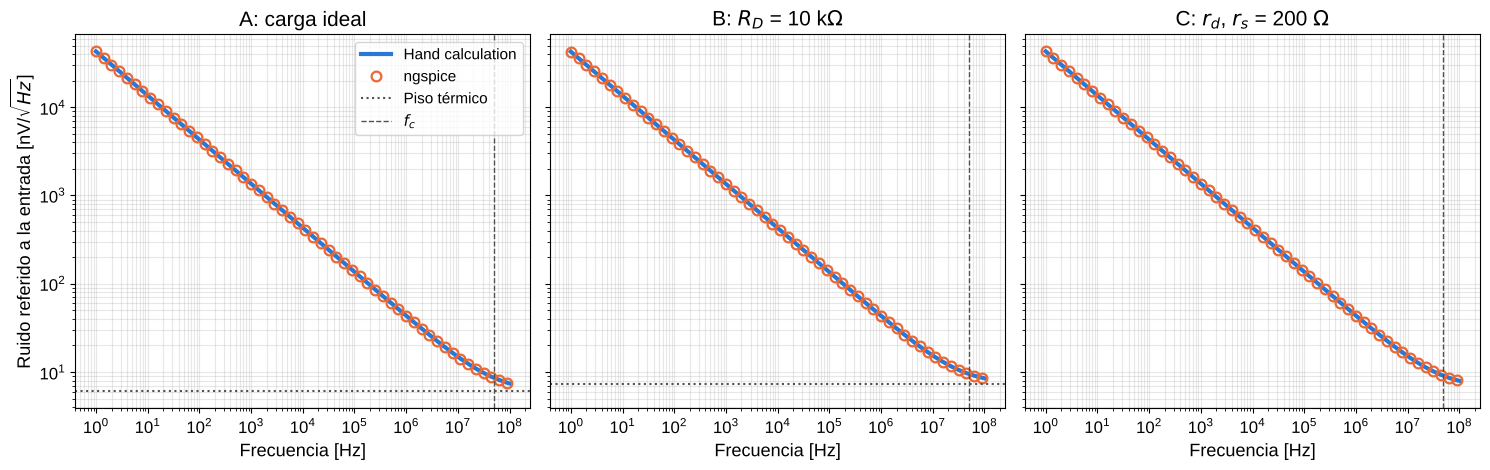

In [9]:
# Tres paneles (A, B, C) con el ruido referido a la entrada: calculo a mano, ngspice, piso termico y esquina
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

titulos = ["A: carga ideal", r"B: $R_D$ = 10 k$\Omega$", r"C: $r_d$, $r_s$ = 200 $\Omega$"]
curvas_hand = [Sin_A_hand, Sin_B_hand, Sin_C_hand]
curvas_sim = [Sin_A_sim, Sin_B_sim, Sin_C_sim]
esquinas = [fc_A, fc_B, fc_C]
pisos_termicos = [S_vin_th_A, sin_B_th, None]       # En C no hay un piso simple: rs y rd lo modifican

for ax, titulo, h, s, fc, piso in zip(axes, titulos, curvas_hand, curvas_sim, esquinas, pisos_termicos):
    ax.loglog(f, np.sqrt(h) * 1e9, linewidth=3, color=C_HAND, label="Hand calculation")
    ax.loglog(f[::3], np.sqrt(s[::3]) * 1e9, 'o', markersize=7, mfc='none', mew=1.6, color=C_SIM, label="ngspice")
    if piso is not None:
        ax.axhline(np.sqrt(piso) * 1e9, color=C_AUX, linestyle=':', linewidth=1.5, label="Piso térmico")
    ax.axvline(fc, color=C_AUX, linestyle='--', linewidth=1, label=r"$f_c$")
    ax.set_title(titulo, fontsize=15, weight='normal')
    ax.set_xlabel("Frecuencia [Hz]", fontsize=13)
    ax.tick_params(labelsize=12)
    ax.grid(which='both', alpha=0.3)

axes[0].set_ylabel(r"Ruido referido a la entrada [nV/$\sqrt{Hz}$]", fontsize=13)
axes[0].legend(fontsize=11, loc="upper right")
fig.tight_layout()
plt.show()

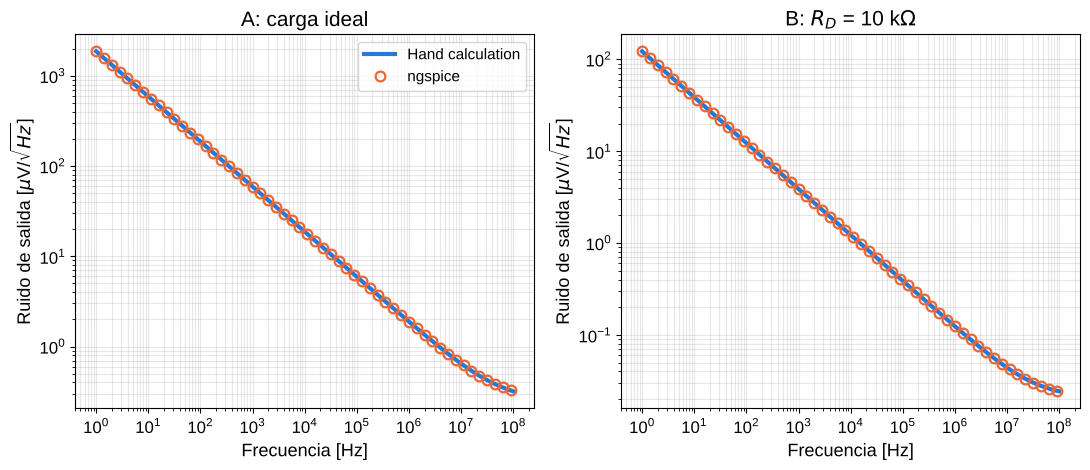

In [10]:
# Dos paneles (A y B) con el ruido de salida
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

titulos = ["A: carga ideal", r"B: $R_D$ = 10 k$\Omega$"]
curvas_hand = [Sout_A_hand, Sout_B_hand]
curvas_sim = [Sout_A_sim, Sout_B_sim]

for ax, titulo, h, s in zip(axes, titulos, curvas_hand, curvas_sim):
    ax.loglog(f, np.sqrt(h) * 1e6, linewidth=3, color=C_HAND, label="Hand calculation")
    ax.loglog(f[::3], np.sqrt(s[::3]) * 1e6, 'o', markersize=7, mfc='none', mew=1.6, color=C_SIM, label="ngspice")
    ax.set_title(titulo, fontsize=15, weight='normal')
    ax.set_xlabel("Frecuencia [Hz]", fontsize=13)
    ax.set_ylabel(r"Ruido de salida [$\mu$V/$\sqrt{Hz}$]", fontsize=13)
    ax.tick_params(labelsize=12)
    ax.grid(which='both', alpha=0.3)

axes[0].legend(fontsize=11, loc="upper right")
fig.tight_layout()
plt.show()

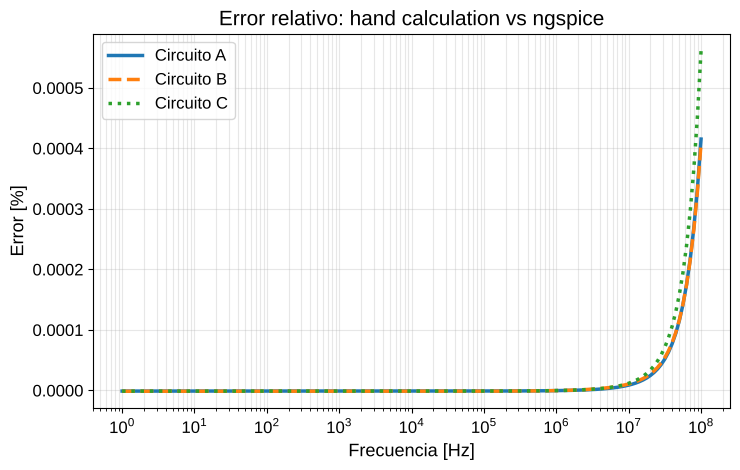

In [11]:
# Error relativo (hand calculation / ngspice - 1) en porcentaje, para los tres circuitos
plt.figure(figsize=(7.5, 4.8))
plt.semilogx(f, (Sin_A_hand / Sin_A_sim - 1) * 100, "-", linewidth=2.5, label="Circuito A")
plt.semilogx(f, (Sin_B_hand / Sin_B_sim - 1) * 100, "--", linewidth=2.5, label="Circuito B")
plt.semilogx(f, (Sin_C_hand / Sin_C_sim - 1) * 100, ":", linewidth=2.5, label="Circuito C")
plt.title("Error relativo: hand calculation vs ngspice", fontsize=15, weight='normal')
plt.xlabel("Frecuencia [Hz]", fontsize=13)
plt.ylabel("Error [%]", fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(which='both', alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Ruido integrado

El ruido rms en una banda $[f_1,\,f_2]$ es la raíz de la integral de la densidad espectral. Para el ruido referido a la entrada de los circuitos A y B, con $S_{V_{in}}(f)=S_{th}+K/f$ y $K=K_FI_D^{A_F}/(g_m^2WLC_{ox}^2)$, la integral tiene forma cerrada:

$$V_{n,in}^2=\int_{f_1}^{f_2}S_{V_{in}}\,df=S_{th}\,(f_2-f_1)+K\ln\frac{f_2}{f_1}.$$

Para el ruido de salida y el circuito C la densidad no es tan simple, así que se integra numéricamente con la regla del trapecio sobre una malla logarítmica densa. ngspice reporta estos totales como `inoise_total` y `onoise_total` en el log, integrados sobre el mismo barrido de 1 Hz a 100 MHz.

In [12]:
# Paso 1: leer los totales integrados que ngspice escribio en el log (orden: A, B, C)
log_txt = open("Noise_Razavi.log", encoding="utf-8", errors="ignore").read()
inoise_tot = [float(x) for x in re.findall(r"^inoise_total\s*=\s*([-+0-9.eE]+)", log_txt, flags=re.M)]
onoise_tot = [float(x) for x in re.findall(r"^onoise_total\s*=\s*([-+0-9.eE]+)", log_txt, flags=re.M)]

# Paso 2: banda de integracion y malla logaritmica densa para la regla del trapecio
f1 = f[0]
f2 = f[-1]
fd = np.logspace(np.log10(f1), np.log10(f2), 200001)

# ===================== Circuito A =====================
# Paso 3: densidad referida a la entrada en la malla densa, y su integral numerica
Si_A_d = S_id_th_A + kf * ID_A**af / (fd * W * L * Cox**2)
Vin_A_num = np.sqrt(trapz(Si_A_d / gm_A**2, fd))
# Paso 4: forma cerrada, S_Vin = S_th + K/f  ->  Vn^2 = S_th*(f2 - f1) + K*ln(f2/f1)
S_th_A = S_id_th_A / gm_A**2
K_A = kf * ID_A**af / (gm_A**2 * W * L * Cox**2)
Vin_A_cerrada = np.sqrt(S_th_A * (f2 - f1) + K_A * np.log(f2 / f1))
# Paso 5: ruido de salida integrado
Vout_A_num = np.sqrt(trapz(Si_A_d / (gds_A**2 + (2 * np.pi * fd * Cout)**2), fd))

# ===================== Circuito B =====================
# Paso 3: igual que A, sumando el ruido de RD
Si_B_d = S_id_th_B + kf * ID_B**af / (fd * W * L * Cox**2) + 4 * k * T / RD
Vin_B_num = np.sqrt(trapz(Si_B_d / gm_B**2, fd))
# Paso 4: forma cerrada; el termico incluye el aporte de RD
S_th_B = (S_id_th_B + 4 * k * T / RD) / gm_B**2
K_B = kf * ID_B**af / (gm_B**2 * W * L * Cox**2)
Vin_B_cerrada = np.sqrt(S_th_B * (f2 - f1) + K_B * np.log(f2 / f1))
# Paso 5: ruido de salida integrado
Vout_B_num = np.sqrt(trapz(Si_B_d / (G_B**2 + (2 * np.pi * fd * Cout)**2), fd))

# ===================== Circuito C =====================
# Paso 3: suma de las tres fuentes (canal, rd, rs) en la malla densa; las H y Av ya se calcularon
S_ch_C_d = S_id_th_C + kf * ID_C**af / (fd * W * L * Cox**2)
Sin_C_d = (S_ch_C_d * H_ch**2 + S_rd * H_rd**2 + S_rs * H_rs**2) / Av_C**2
Vin_C_num = np.sqrt(trapz(Sin_C_d, fd))

# ===================== Resultados =====================
myTable = PrettyTable(["Circuito", "Vin rms hand (numerico)", "Vin rms hand (forma cerrada)", "Vin rms ngspice", "Error"])
myTable.add_row(["A", num2eng(float(Vin_A_num)) + "V", num2eng(float(Vin_A_cerrada)) + "V", num2eng(inoise_tot[0]) + "V",
                 f"{(Vin_A_num / inoise_tot[0] - 1) * 100:+.3f} %"])
myTable.add_row(["B", num2eng(float(Vin_B_num)) + "V", num2eng(float(Vin_B_cerrada)) + "V", num2eng(inoise_tot[1]) + "V",
                 f"{(Vin_B_num / inoise_tot[1] - 1) * 100:+.3f} %"])
myTable.add_row(["C", num2eng(float(Vin_C_num)) + "V", "-", num2eng(inoise_tot[2]) + "V",
                 f"{(Vin_C_num / inoise_tot[2] - 1) * 100:+.3f} %"])
print(f"Ruido integrado de {f1:.0f} Hz a {f2 / 1e6:.0f} MHz, referido a la entrada\n")
print(myTable)

myTable = PrettyTable(["Circuito", "Vout rms hand", "Vout rms ngspice", "Error"])
myTable.add_row(["A", num2eng(float(Vout_A_num)) + "V", num2eng(onoise_tot[0]) + "V",
                 f"{(Vout_A_num / onoise_tot[0] - 1) * 100:+.3f} %"])
myTable.add_row(["B", num2eng(float(Vout_B_num)) + "V", num2eng(onoise_tot[1]) + "V",
                 f"{(Vout_B_num / onoise_tot[1] - 1) * 100:+.3f} %"])
print("\nReferido a la salida\n")
print(myTable)

Ruido integrado de 1 Hz a 100 MHz, referido a la entrada

+----------+-------------------------+------------------------------+-----------------+----------+
| Circuito | Vin rms hand (numerico) | Vin rms hand (forma cerrada) | Vin rms ngspice |  Error   |
+----------+-------------------------+------------------------------+-----------------+----------+
|    A     |         194.1 µV        |           194.1 µV           |     194.1 µV    | -0.008 % |
|    B     |         197.4 µV        |           197.4 µV           |     197.4 µV    | -0.000 % |
|    C     |         196.3 µV        |              -               |     196.3 µV    | -0.012 % |
+----------+-------------------------+------------------------------+-----------------+----------+

Referido a la salida

+----------+---------------+------------------+----------+
| Circuito | Vout rms hand | Vout rms ngspice |  Error   |
+----------+---------------+------------------+----------+
|    A     |     8.5 mV    |      8.5 mV      | +

## Cómo elegir $K_F$

Con $A_F=1$ y en saturación, $f\cdot S_{V_{in},fl}$ no depende de la polarización (sección de ruido flicker), así que $K_F$ se puede despejar a partir de una densidad de ruido 1/f referida a la entrada que se quiera reproducir:

$$K_F=2\,k_p\,W^2\,C_{ox}^2\,(1+\lambda V_{DS})\cdot\left[f\cdot S_{V_{in},fl}\right].$$

Si el dato disponible es la densidad a 1 Hz en V/$\sqrt{\text{Hz}}$, basta elevarla al cuadrado. Este $K_F$ es el de la expresión del Level 1 de ngspice; no es el $K_F'$ (en V$^2\cdot$F) que suelen reportar las fundiciones. La relación entre ambos depende de la forma de la fórmula que use cada simulador, así que conviene calibrar contra el propio simulador.

In [13]:
# Paso 1: densidad de ruido 1/f referida a la entrada que se quiere reproducir, a 1 Hz
objetivo = 43e-6                   # V/rtHz (valor del NMOS de la libreria)
S_in_1Hz_objetivo = objetivo**2    # V^2/Hz

# Paso 2: despejar KF (af = 1, saturacion, W = 1 um, L = 0.18 um, VDS = 0.9 V)
kf_necesario = 2 * kp * W**2 * Cox**2 * (1 + lmbda * VDS_A) * S_in_1Hz_objetivo

print(f"Para {objetivo * 1e6:.2f} uV/rtHz a 1 Hz (af = 1, W = 1u, L = 0.18u): KF = {kf_necesario:.3e}   (usado en la libreria: {kf:.1e})")

Para 43.00 uV/rtHz a 1 Hz (af = 1, W = 1u, L = 0.18u): KF = 3.004e-29   (usado en la libreria: 3.0e-29)


## Diferencias entre ngspice y LTspice

Los mismos tres circuitos (A, B y C) se simularon también en LTspice (`LTspice/Razavi/Noise_A`, `Noise_B` y `Noise_C`; el cálculo y la comparación están en `LTspice/Razavi/LTspice_Noise.ipynb`). La topología, el punto de operación y el ruido térmico coinciden en los dos simuladores. **El ruido flicker no:** el Level 1 se implementa con fórmulas distintas.

| | ngspice | LTspice |
|---|---|---|
| $S_{I_D,fl}$ | $\dfrac{K_F\,I_D^{A_F}}{f\,W L\,C_{ox}^2}$ | $\dfrac{K_F\,g_m^2}{f\,W L\,C_{ox}}$ |
| $S_{V_{in},fl}$ | $\dfrac{K_F\,I_D^{A_F}}{g_m^2\,f\,W L\,C_{ox}^2}$ | $\dfrac{K_F}{f\,W L\,C_{ox}}$ (no depende de la polarización) |
| Escala con $W$ (a igual $L$ y polarización) | $1/W^2$ | $1/W$ |
| $K_F$ en `razavi_cmos.lib` (NMOS / PMOS) | $3\times10^{-29}$ / $3.5\times10^{-30}$ | $2.87\times10^{-24}$ / $6.7\times10^{-25}$ |

La fórmula de LTspice se dedujo de sus resultados: en los `.raw` de los tres circuitos, $f\cdot S_{V_{in},fl}$ es constante e igual a $K_F/(WLC_{ox})$ con 7 cifras. Solo se verificó con $A_F=1$.

**Consecuencias**

* **El mismo $K_F$ no sirve en los dos simuladores.** Con $K_F=3\times10^{-29}$ en LTspice, el flicker sería de 139 nV/$\sqrt{\text{Hz}}$ a 1 Hz y la esquina de unos 500 Hz, en lugar de 43 µV/$\sqrt{\text{Hz}}$ y 51 MHz.
* **Equivalencia** para $W=1\,\mu$m, $L=0.18\,\mu$m y $V_{DS}=0.9$ V:
$$K_{F,LT}=K_{F,ng}\,\frac{L}{2\,k_p\,W\,C_{ox}\,(1+\lambda V_{DS})}\approx9.6\times10^{4}\,K_{F,ng}.$$
  Depende de la geometría y de la polarización, así que si se cambian hay que recalcular el $K_F$ de LTspice.
* **Resultado.** Con los $K_F$ de cada librería, LTspice y ngspice coinciden con el cálculo a mano: el error máximo entre ambos simuladores es 0.02 % (A), 1.25 % (B) y 0.23 % (C) en la densidad espectral referida a la entrada. En B y C la diferencia viene de que el flicker de ngspice depende de la polarización ($V_{DS}=1.03$ V en B; $r_s$ y $r_d$ en C) y el de LTspice no.
* **Calibración con los PDKs.** El procedimiento de las secciones siguientes ($K_F^{eq}$ medido en sky130 y gf180) está hecho para la fórmula de ngspice. Para LTspice se obtiene el $K_F$ con la equivalencia anterior o, directamente, con $K_F=S_{V_{in},fl}\cdot f\cdot W L\,C_{ox}$ a partir del ruido referido a la entrada del PDK.


## Hallazgos: el ruido del Level 1 frente a sky130 y gf180mcuD

Para elegir $K_F$ y $A_F$ se midió el ruido de los PDKs sky130 y gf180mcuD en ngspice (`Extraccion_KF_AF.ipynb`) y se tradujo a los parámetros del Level 1. Estos son los hallazgos y las diferencias con el modelo de Razavi.

### Cómo modela cada uno el ruido

| | Level 1 (Razavi) | sky130 (`nfet_01v8`, `pfet_01v8`) | gf180mcuD (`nfet_03v3`, `pfet_03v3`) |
|---|---|---|---|
| Modelo | SPICE Level 1 | BSIM4 v4.5 (`level=54`) | BSIM4 v4.5 (`level=54`) |
| Ruido térmico del canal | $4kT\cdot\frac23 g_m$, fijo | `tnoimod=1` (modelo holístico) | `tnoimod=0` (basado en carga) |
| Ruido flicker | $K_F I_D^{A_F}/(f\,WL\,C_{ox}^2)$ | `fnoimod=1`: `noia`, `noib`, `noic`, `em`, `ef` | igual, con el interruptor `fnoicor` |
| `kf` y `af` | **sí se usan** | `kf=0`, `af=1` en la tarjeta (no se usan con `fnoimod=1`) | no aparecen en los modelos `nfet_03v3` / `pfet_03v3` |
| Exponente de frecuencia | 1 fijo | `ef` (medido: 0.84 NMOS, 1.00 PMOS) | `ef` (medido: 0.95 NMOS, 1.12 PMOS) |
| Esquina de ruido del PDK | — | — | `fnoicor=1`: peor caso (×10 NMOS, ×6 PMOS) |

En ambos PDKs la información de ruido no está en `kf`/`af`, sino en los parámetros del modelo unificado de flicker; por eso no se pueden copiar y hubo que **medir** el ruido y ajustar.

### Qué se midió

Condiciones: $W=1\,\mu$m, $I_D\approx76\,\mu$A, $V_{DS}=V_{DD}/2$, longitud mínima de cada PDK (0.18 µm en sky130 y 0.28 µm en gf180mcuD), carga ideal y esquina típica. $K_F^{eq}$ usa la $C_{ox}$ de Razavi ($t_{ox}=4$ nm) y $A_F=1$.

| | $K_F^{eq}$ a 1 Hz | $K_F^{eq}$ a 1 kHz | $A_F^{eff}$ (10–200 µA) | $E_F^{eff}$ |
|---|---|---|---|---|
| sky130 NMOS | $2.0\times10^{-29}$ | $6.1\times10^{-29}$ | 0.71 | 0.84 |
| sky130 PMOS | $1.4\times10^{-30}$ | $1.4\times10^{-30}$ | 0.74 (10–120 µA) | 1.00 |
| gf180 NMOS | $1.9\times10^{-29}$ | $2.7\times10^{-29}$ | 0.86 | 0.95 |
| gf180 PMOS | $1.3\times10^{-29}$ | $5.8\times10^{-30}$ | 1.30 | 1.12 |

### Valores elegidos para `razavi_cmos.lib`

$A_F=1$ en ambos, $K_F=3\times10^{-29}$ (NMOS) y $K_F=3.5\times10^{-30}$ (PMOS). Quedan dentro de un factor de ~1.5 de los dos PDKs en el NMOS; en el PMOS ambos PDKs difieren entre sí (~×10 a 1 Hz), y el valor elegido queda entre los dos (×2.5 sobre sky130, ×0.26 a ×0.60 de gf180). Con $W=1\,\mu$m, $L=0.18\,\mu$m y $|V_{GS}|=0.9$ V:

| | $K_F$ | $\sqrt{S_{V_{in},fl}}$ a 1 Hz | $f_c$ |
|---|---|---|---|
| NMOS | $3\times10^{-29}$ | 43 µV/√Hz | ≈51 MHz |
| PMOS | $3.5\times10^{-30}$ | 21 µV/√Hz | ≈5.9 MHz |

### Diferencias importantes entre el Level 1 y los PDKs

1. **Geometría.** El Level 1 escala el flicker como $1/(WL)$ a igual $I_D$. En los PDKs, a igual $I_D/W$, $K_F^{eq}$ crece con $W$ y baja con $L$ (hasta un orden de magnitud entre $L$ mínima y $L=1\,\mu$m). Los valores elegidos valen para $W\approx1\,\mu$m y $L$ cercana a la mínima.
2. **Frecuencia.** El Level 1 solo tiene flicker exactamente $1/f$. En gf180mcuD el exponente es 0.95 (NMOS) y 1.12 (PMOS), y en sky130 0.84 (NMOS): $K_F^{eq}$ depende de la frecuencia en la que se calibre (se eligió un valor entre 1 Hz y 1 kHz).
3. **Corriente.** Con $A_F=1$ el flicker crece linealmente con $I_D$; los PDKs tienen exponentes efectivos de 0.7 a 1.3, así que la dependencia real con la polarización es distinta.
4. **Ruido térmico.** El Level 1 usa $\gamma=2/3$; en gf180mcuD el ruido térmico medido equivale a $\gamma\approx1$ a 1.1 (efecto de canal corto y de $g_m$ del BSIM4).
5. **Esquinas.** Con estos $K_F$ la esquina del NMOS queda en ≈51 MHz y la del PMOS en ≈5.9 MHz, del mismo orden que las medidas en gf180mcuD con $W=1\,\mu$m y $I_D=76\,\mu$A (≈52 MHz y ≈4.8 MHz). Si se prefiere una esquina cercana a 1 MHz en el NMOS, basta usar $K_F\approx10^{-30}$, a costa de alejarse de los PDKs.

El Level 1 sirve entonces para enseñar la **estructura** del ruido (térmico + flicker, referido a la entrada y a la salida, integración, efecto de $R_D$, $r_d$ y $r_s$) con magnitudes realistas, pero no reproduce la dependencia con la geometría, la polarización y la frecuencia de un modelo comercial.
